In [28]:
from pathlib import Path

REPO_ROOT = Path().cwd().parent

OUT_ROOT = REPO_ROOT / "Topic_2" / "Output"

PLOT_ROOT = REPO_ROOT / "Topic_2" / "Plots"

In [29]:
import geopandas as gpd
import pandas as pd
import numpy as np

berlin = gpd.read_file(OUT_ROOT / "1_postcode_city_shapefiles" / "postcodes_berlin.shp")
frankfurt = gpd.read_file(OUT_ROOT / "1_postcode_city_shapefiles" / "postcodes_frankfurt_am_main.shp")
muenchen = gpd.read_file(OUT_ROOT / "1_postcode_city_shapefiles" / "postcodes_muenchen.shp")
hamburg = gpd.read_file(OUT_ROOT / "1_postcode_city_shapefiles" / "postcodes_hamburg.shp")
koeln = gpd.read_file(OUT_ROOT / "1_postcode_city_shapefiles" / "postcodes_koeln.shp")

index_wm = pd.read_csv(OUT_ROOT / "2_index_values" / "index_wm_long.csv")
index_wk = pd.read_csv(OUT_ROOT / "2_index_values" / "index_wk_long.csv")
index_hk = pd.read_csv(OUT_ROOT / "2_index_values" / "index_hk_long.csv")


In [30]:
index_wm

,target_id,year,price,price_se,lprice,lprice_se,target_X,target_Y,outer_radius_used,inner_radius_used,outer_obs_used,inner_obs_used
0,10115,2007,534.172361,12.915366,6.280719,0.023891,797406.274895,5.829286e+06,0.763290,0.095800,832,40
1,10115,2008,598.688367,16.661675,6.394741,0.027450,797406.274895,5.829286e+06,0.763290,0.095800,368,23
2,10115,2009,582.734470,9.504290,6.367732,0.016178,797406.274895,5.829286e+06,0.763290,0.095800,191,54
3,10115,2010,660.133652,21.068023,6.492442,0.031416,797406.274895,5.829286e+06,0.763290,0.095800,397,16
4,10115,2011,715.338041,10.082480,6.572755,0.013996,797406.274895,5.829286e+06,0.763290,0.095800,344,20
...,...,...,...,...,...,...,...,...,...,...,...,...
7179,85579,2018,717.958072,322.945210,6.576411,0.371433,696779.241678,5.328509e+06,2.216595,1.016919,221,14
7180,85579,2019,752.001418,57.145278,6.622738,0.073242,696779.241678,5.328509e+06,2.216595,1.016919,588,182
7181,85579,2020,975.910849,130.609213,6.883371,0.125604,696779.241678,5.328509e+06,2.216595,1.016919,302,40
7182,85579,2021,953.199066,28.973364,6.859824,0.029943,696779.241678,5.328509e+06,2.216595,1.016919,244,10


In [31]:
index = [index_wm, index_wk, index_hk]
index_names = ["index_wm", "index_wk", "index_hk"]
cities = {
    "Berlin": berlin,
    "Frankfurt am Main": frankfurt,
    "München": muenchen,
    "Hamburg": hamburg,
    "Köln": koeln
}

# Initialize nested dictionaries for each city
index_dict = {city_name: {} for city_name in cities.keys()}

for idx, city_name in enumerate(cities.keys()):
    for i, df in enumerate(index):
        # Convert postal5 to integers to match target_id type
        postal5_int = cities[city_name]["postal5"].astype(int).unique()
        city_index = df[df["target_id"].isin(postal5_int)]
        if not city_index.empty:
            # Use index names as keys instead of DataFrame objects
            index_dict[city_name][index_names[i]] = city_index

In [32]:
# Check index_dict structure
print("index_dict structure:")
for city, indices in index_dict.items():
    print(f"\n{city}:")
    for index_name, df in indices.items():
        print(f"  {index_name}: {len(df)} rows")

index_dict structure:

Berlin:
  index_wm: 2976 rows
  index_wk: 2976 rows
  index_hk: 2976 rows

Frankfurt am Main:
  index_wm: 608 rows
  index_wk: 608 rows
  index_hk: 608 rows

München:
  index_wm: 1168 rows
  index_wk: 1168 rows
  index_hk: 1168 rows

Hamburg:
  index_wm: 1584 rows
  index_wk: 1584 rows
  index_hk: 1584 rows

Köln:
  index_wm: 720 rows
  index_wk: 720 rows
  index_hk: 720 rows


In [33]:
berlin_grid = gpd.read_file(OUT_ROOT / "3_cbd" / "grid_11" / "grid_11.shp")
frankfurt_grid = gpd.read_file(OUT_ROOT / "3_cbd" / "grid_37" / "grid_37.shp")
muenchen_grid = gpd.read_file(OUT_ROOT / "3_cbd" / "grid_75" / "grid_75.shp")
hamburg_grid = gpd.read_file(OUT_ROOT / "3_cbd" / "grid_43" / "grid_43.shp")

# Replace 0s with NaN in the employment share column
berlin_grid["emp_sh"] = berlin_grid["emp_sh"].replace(0, np.nan)
frankfurt_grid["emp_sh"] = frankfurt_grid["emp_sh"].replace(0, np.nan)
muenchen_grid["emp_sh"] = muenchen_grid["emp_sh"].replace(0, np.nan)
hamburg_grid["emp_sh"] = hamburg_grid["emp_sh"].replace(0, np.nan)

berlin_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "shape_11" / "PL_11.shp")
frankfurt_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "shape_37" / "PL_37.shp")
muenchen_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "shape_75" / "PL_75.shp")
hamburg_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "shape_43" / "PL_43.shp")

# Try to load koeln_PL if it exists
try:
    koeln_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "shape_51" / "PL_51.shp")
except:
    koeln_PL = None
    print("Warning: Köln PL shapefile not found")

berlin_price_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "berlin" / "berlin_cbd_centroid.csv")
frankfurt_price_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "frankfurt_am_main" / "frankfurt_am_main_cbd_centroid.csv")
muenchen_price_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "muenchen" / "muenchen_cbd_centroid.csv")
hamburg_price_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "hamburg" / "hamburg_cbd_centroid.csv")
koeln_price_PL = gpd.read_file(OUT_ROOT / "3_cbd" / "koeln" / "koeln_cbd_centroid.csv")

berlin_price_PL = gpd.GeoDataFrame(berlin_price_PL, geometry=gpd.points_from_xy(berlin_price_PL.cbd_lon, berlin_price_PL.cbd_lat), crs="EPSG:4326").to_crs("EPSG:25832")
frankfurt_price_PL = gpd.GeoDataFrame(frankfurt_price_PL, geometry=gpd.points_from_xy(frankfurt_price_PL.cbd_lon, frankfurt_price_PL.cbd_lat), crs="EPSG:4326").to_crs("EPSG:25832")
muenchen_price_PL = gpd.GeoDataFrame(muenchen_price_PL, geometry=gpd.points_from_xy(muenchen_price_PL.cbd_lon, muenchen_price_PL.cbd_lat), crs="EPSG:4326").to_crs("EPSG:25832")
hamburg_price_PL = gpd.GeoDataFrame(hamburg_price_PL, geometry=gpd.points_from_xy(hamburg_price_PL.cbd_lon, hamburg_price_PL.cbd_lat), crs="EPSG:4326").to_crs("EPSG:25832")
koeln_price_PL = gpd.GeoDataFrame(koeln_price_PL, geometry=gpd.points_from_xy(koeln_price_PL.cbd_lon, koeln_price_PL.cbd_lat), crs="EPSG:4326").to_crs("EPSG:25832")

In [34]:
# Set up for plotting
# Params for clean and minimalistic plots

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (6*2, 2*4.5),
    'font.size': 14.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

In [35]:
choose_top_proc = float(0.1)

# Prepare data for all cities
cities_data = [
    (berlin_grid, berlin, "Berlin", berlin_PL, berlin_price_PL),
    (frankfurt_grid, frankfurt, "Frankfurt am Main", frankfurt_PL, frankfurt_price_PL),
    (muenchen_grid, muenchen, "München", muenchen_PL, muenchen_price_PL),
    (hamburg_grid, hamburg, "Hamburg", hamburg_PL, hamburg_price_PL)
]

weighted_emp_centroids = {}

# For each city, calculate the emp_sh weighted centroid of top grid cells

for grid, city, city_name, _, _ in cities_data:
    threshold = grid['emp_sh'].quantile(1 - choose_top_proc)
    top_grid = grid[grid['emp_sh'] >= threshold]
    
    # Calculate weighted centroid
    top_grid = top_grid.to_crs("EPSG:25832")  # Use a projected CRS for accurate area calculations
    top_grid.geometry = top_grid.geometry.centroid  # Use centroids for weighting
    
    # Calculate weighted average of centroids
    weights = top_grid['emp_sh']
    weighted_centroid_x = (top_grid.geometry.x * weights).sum() / weights.sum()
    weighted_centroid_y = (top_grid.geometry.y * weights).sum() / weights.sum()
    
    weighted_emp_centroids[str(city_name) + "_geo"] = (weighted_centroid_x, weighted_centroid_y)
    weighted_emp_centroids[str(city_name) + "_emp_sh"] = top_grid['emp_sh'].sum()
    

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/1038373929.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area = gpd.GeoSeries([city.to_crs("EPSG:25832").unary_union]).geometry.area.sum()
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/1038373929.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area = gpd.GeoSeries([city.to_crs("EPSG:25832").unary_union]).geometry.area.sum()
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/1038373929.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area = gpd.GeoSeries([city.to_crs("EPSG:25832").unary_union]).geometry.area.sum()
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/1038373929.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area = gpd

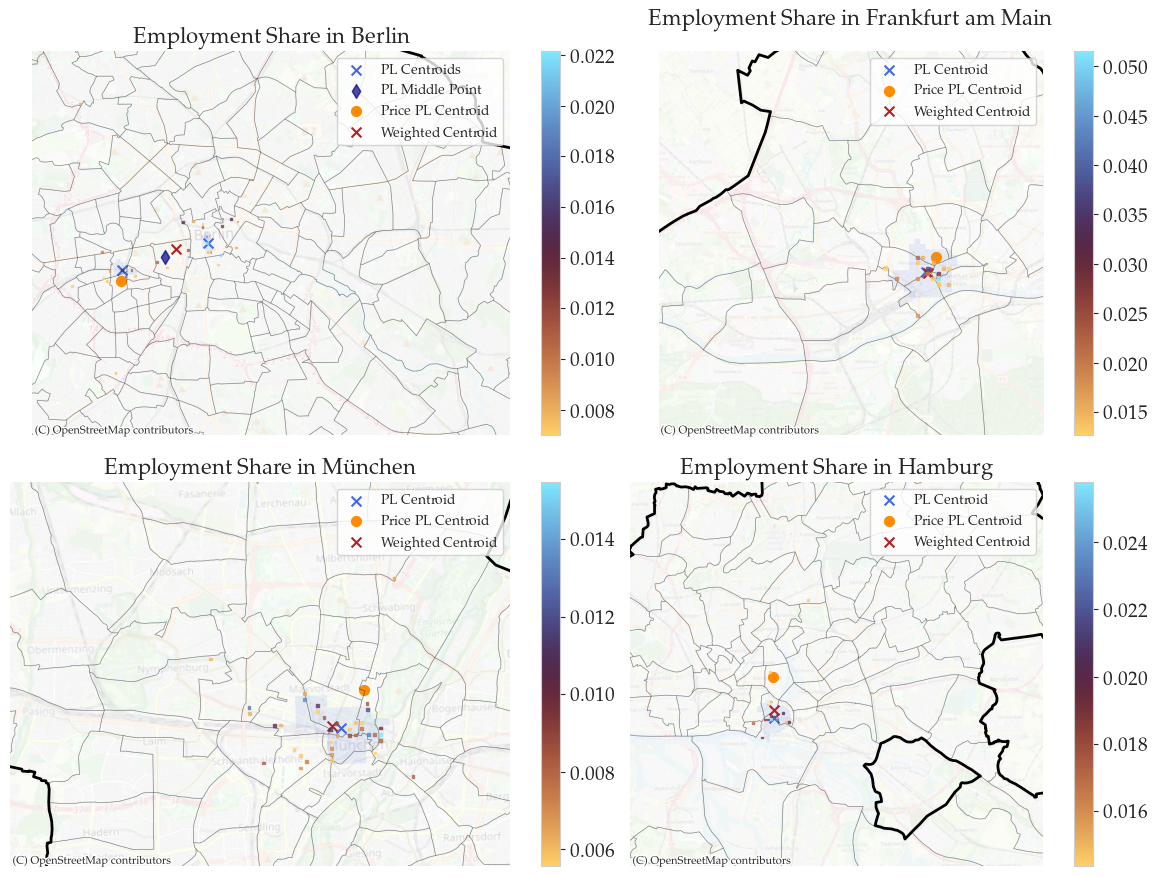

In [36]:
# Plot the employment share column and the border of each city in a 2x2 matrix

import contextily as ctx

# Calculate markersize for each city based on its area
# Smaller cities get larger markers for visibility
markersize_reference = 10  # Reference markersize for base scale
areas = []
for grid, city, city_name, _, _ in cities_data:
    area = gpd.GeoSeries([city.to_crs("EPSG:25832").unary_union]).geometry.area.sum()
    areas.append(area)

# Normalize markersize inversely to area
min_area = min(areas)
markersizes = [markersize_reference * (min_area / area) for area in areas]

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()  # Flatten to make indexing easier

for idx, (grid, city, city_name, pl, price_pl) in enumerate(cities_data):
    ax = axes[idx]
    
    # Calculate threshold and filter top cells
    threshold = grid['emp_sh'].quantile(1 - choose_top_proc)
    top_grid = grid[grid['emp_sh'] >= threshold]
    
    # Transform the geometries 
    top_grid = top_grid.to_crs("EPSG:25832")
    
    # Use centroid-based markersize for better visibility
    top_grid.geometry = top_grid.geometry.centroid
    
    # Plot the top grid cells with adapted markersize and square markers for better visibility
    top_grid.plot(column="emp_sh", ax=ax, legend=True, cmap="managua", markersize=markersizes[idx]*0.5, marker="s", alpha=0.7, zorder=3)
    
    if len(pl) == 1:
        pl = pl.to_crs("EPSG:25832")
        pl.plot(ax=ax, facecolor='royalblue', edgecolor='none', alpha=0.1)
        pl.geometry = pl.geometry.centroid
        pl.plot(ax=ax, color='royalblue', markersize=50, marker='x', label='PL Centroid')
    else:
        pl = pl.to_crs("EPSG:25832")
        pl.plot(ax=ax, facecolor='royalblue', edgecolor='none', alpha=0.1)
        pl.geometry = pl.geometry.centroid
        pl.plot(ax=ax, color='royalblue', markersize=50, marker='x', label='PL Centroids')
        
        # Compute the middle point of multiple PLs
        middle_x = pl.geometry.x.mean()
        middle_y = pl.geometry.y.mean()
        ax.scatter(middle_x, middle_y, color='navy', s=50, marker='d', label='PL Middle Point', alpha=0.7)
        
    # Plot the price PL centroid
    price_pl.plot(ax=ax, color='darkorange', markersize=50, marker='o', label='Price PL Centroid')
    
    # Plot the city boundary
    gpd.GeoSeries([city.to_crs("EPSG:25832").unary_union]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
    city.to_crs("EPSG:25832").plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, alpha=0.25)
    
    # Plot the weighted centroid
    centroid_x, centroid_y = weighted_emp_centroids[str(city_name) + "_geo"]
    ax.scatter(centroid_x, centroid_y, color='firebrick', s=50, marker='x', label='Weighted Centroid')
    ax.legend(fontsize=10)
    
    # Zoom based on city boundary - shows consistent proportion of each city
    city_bounds = city.to_crs("EPSG:25832").total_bounds  # [minx, miny, maxx, maxy]
    # Use a consistent 10% buffer relative to city boundary
    buffer_x = (city_bounds[2] - city_bounds[0]) * (-0.25)
    buffer_y = (city_bounds[3] - city_bounds[1]) * (-0.25)
    
    ax.set_xlim(city_bounds[0] - buffer_x, city_bounds[2] + buffer_x)
    ax.set_ylim(city_bounds[1] - buffer_y, city_bounds[3] + buffer_y)
    
    # Set equal aspect ratio to prevent distortion
    ax.set_aspect('equal')
    
    ax.set_title(f"Employment Share in {city_name}", fontsize=16)
    ax.set_axis_off()
    
    # Add OpenStreetMap background (low zorder so it stays in background)
    ctx.add_basemap(ax, crs="EPSG:25832", source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.2, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_ROOT / "task_3" / "employment_share_cbd_comparison.png", dpi=300)
plt.show()

In [37]:
weighted_emp_centroids

{'Berlin_geo': (np.float64(796300.9049668249), np.float64(5827007.629581258)),
 'Berlin_emp_sh': np.float64(0.3323199319000001),
 'Frankfurt am Main_geo': (np.float64(476320.8732968312),
  np.float64(5551208.298882304)),
 'Frankfurt am Main_emp_sh': np.float64(0.355872779),
 'München_geo': (np.float64(690909.1684056958), np.float64(5335251.978311193)),
 'München_emp_sh': np.float64(0.3090995437),
 'Hamburg_geo': (np.float64(565694.3192670026), np.float64(5934391.104616906)),
 'Hamburg_emp_sh': np.float64(0.27590078)}

In [38]:
# For each city we collect the cbds in one dataframe
berlin_cbd = berlin_price_PL.copy()
frankfurt_cbd = frankfurt_price_PL.copy()
muenchen_cbd = muenchen_price_PL.copy()
hamburg_cbd = hamburg_price_PL.copy()
koeln_cbd = koeln_price_PL.copy()

berlin_cbd['type'] = "Index_PL"
frankfurt_cbd['type'] = "Index_PL"
muenchen_cbd['type'] = "Index_PL"
hamburg_cbd['type'] = "Index_PL"
koeln_cbd['type'] = "Index_PL"

# Collect city GeoDataFrames in a dictionary for easier access
city_gdfs = {
    "Berlin": berlin_cbd,
    "Frankfurt am Main": frankfurt_cbd,
    "München": muenchen_cbd,
    "Hamburg": hamburg_cbd,
    "Köln": koeln_cbd
}

# Add the weighted_emp_centroids as new rows to the respective city dataframes
for city_name in weighted_emp_centroids.keys():
    # Skip non-city entries (e.g., "_geo", "_emp_sh" keys)
    if city_name.endswith("_geo"):
        city_key = city_name.replace("_geo", "")
        if city_key in city_gdfs:
            centroid_x, centroid_y = weighted_emp_centroids[city_name]
            emp_sh_value = weighted_emp_centroids[city_key + "_emp_sh"]
            
            new_row = {
                'city': city_key,
                'cbd_lon': centroid_x,
                'cbd_lat': centroid_y,
                'method': 'emp_sh_weighted_centroid',
                'type': 'Weighted_Centroid',
                'n_postcodes': np.nan,  # Not applicable for the weighted centroid
                'emp_sh': emp_sh_value,
                'geometry': gpd.points_from_xy([centroid_x], [centroid_y])[0]
            }
            
            # Create GeoDataFrame from the new row and use pd.concat()
            new_row_gdf = gpd.GeoDataFrame([new_row], crs=city_gdfs[city_key].crs)
            city_gdfs[city_key] = pd.concat([city_gdfs[city_key], new_row_gdf], ignore_index=True)

# Update the individual city variables
berlin_cbd = city_gdfs["Berlin"]
frankfurt_cbd = city_gdfs["Frankfurt am Main"]
muenchen_cbd = city_gdfs["München"]
hamburg_cbd = city_gdfs["Hamburg"]
koeln_cbd = city_gdfs["Köln"]

# Add the PL centroids as new rows to the respective city dataframes -> For berlin add only the PL centroid with PLrankByCi == 1 (since there are multiple)

for city_name, city_gdf in city_gdfs.items():
    if city_name == "Berlin":
        pl_centroids = berlin_PL[berlin_PL['PLrankByCi'] == 1].to_crs("EPSG:25832")
    elif city_name == "Frankfurt am Main":
        pl_centroids = frankfurt_PL.to_crs("EPSG:25832")
    elif city_name == "München":
        pl_centroids = muenchen_PL.to_crs("EPSG:25832")
    elif city_name == "Hamburg":
        pl_centroids = hamburg_PL.to_crs("EPSG:25832")
    else:
        continue  # Skip if city is not in the list (e.g., Köln which has no PL data)
    
    for idx, row in pl_centroids.iterrows():
        new_row = {
            'city': city_name,
            'cbd_lon': row.geometry.centroid.x,
            'cbd_lat': row.geometry.centroid.y,
            'method': 'PL_centroid',
            'type': 'PL_Centroid',
            'n_postcodes': np.nan,  # Not applicable for the PL centroid
            'emp_sh': np.nan,  # Not applicable for the PL centroid
            'geometry': row.geometry.centroid
        }
        
        new_row_gdf = gpd.GeoDataFrame([new_row], crs=city_gdfs[city_name].crs)
        city_gdfs[city_name] = pd.concat([city_gdfs[city_name], new_row_gdf], ignore_index=True)
        
# Update the individual city variables again after adding PL centroids
berlin_cbd = city_gdfs["Berlin"]
frankfurt_cbd = city_gdfs["Frankfurt am Main"]
muenchen_cbd = city_gdfs["München"]
hamburg_cbd = city_gdfs["Hamburg"]
koeln_cbd = city_gdfs["Köln"]

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/646557059.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = cities[city_name].to_crs("EPSG:25832").unary_union
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/646557059.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/646557059.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = cities[city_name].to_crs("EPSG:25832").unary_union
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/646557059.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when lege

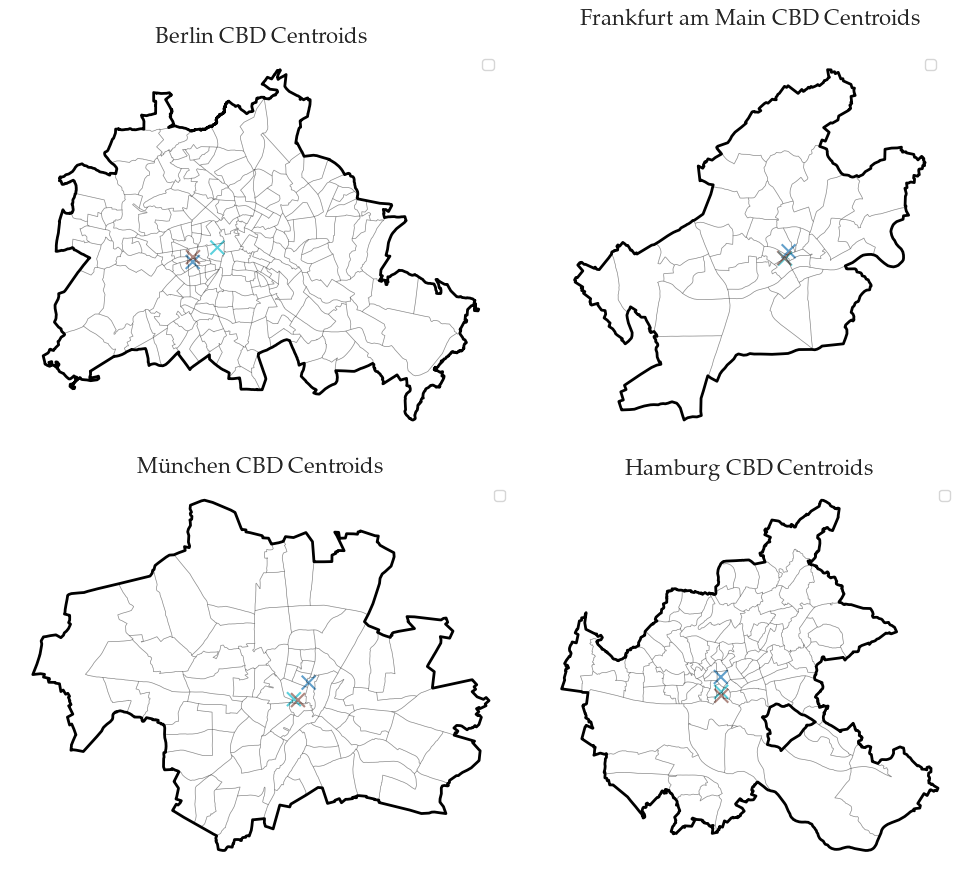

In [39]:
# Plot the updated city dataframes with the new centroids
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()
for idx, (city_name, city_gdf) in enumerate(city_gdfs.items()):
    if city_name == "Köln":
        continue  # Skip Köln for plotting since it has no PL data
    ax = axes[idx]
    
    # Plot the city data
    city_gdf.plot(ax=ax, column='type', categorical=True, legend=True, markersize=100, alpha=0.7, marker = 'x')
    
    # Plot the middle point of PL centroids if there are multiple
    pl_centroids = city_gdf[city_gdf['type'] == 'PL_Centroid']
    if len(pl_centroids) > 1:
        middle_x = pl_centroids.geometry.x.mean()
        middle_y = pl_centroids.geometry.y.mean()
        ax.scatter(middle_x, middle_y, color='navy', s=50, marker='x', label='PL Middle Point', alpha=0.7)

    # Plot the city boundary
    city_boundary = cities[city_name].to_crs("EPSG:25832").unary_union
    gpd.GeoSeries([city_boundary]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
    cities[city_name].to_crs("EPSG:25832").plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, alpha=0.25)
    ax.set_title(f"{city_name} CBD Centroids", fontsize=16)
    ax.set_axis_off()
    ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PLOT_ROOT / "task_3" / "cbd_centroids_comparison.png", dpi=300)
plt.show()
    

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/2267783689.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gpd.GeoSeries([cities[city_name].to_crs("EPSG:25832").unary_union]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/2267783689.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


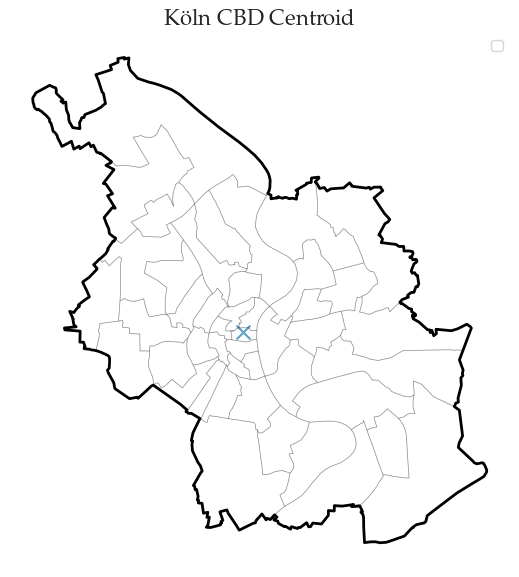

In [40]:
# Plot only for Koeln 
fig, ax = plt.subplots(figsize=(6, 6))
city_name = "Köln"
city_gdf = city_gdfs[city_name]
city_gdf.plot(ax=ax, column='type', categorical=True, legend=True, markersize=100, alpha=0.7, marker = 'x')
# Plot the city boundary
gpd.GeoSeries([cities[city_name].to_crs("EPSG:25832").unary_union]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
cities[city_name].to_crs("EPSG:25832").plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, alpha=0.25)
ax.set_title(f"{city_name} CBD Centroid", fontsize=16)
ax.set_axis_off()
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PLOT_ROOT / "task_3" / "koeln_cbd_centroid.png", dpi=300)
plt.show()

In [41]:
for city in index_dict.keys():
    for index_name in index_dict[city].keys():
        index_df = index_dict[city][index_name]
        cbd_df = city_gdfs[city]
        for idx, cbd_row in cbd_df.iterrows():
            # Compute the distance from the CBD point to centroids of all postcodes in the city and add it as a new column index_df for each cbd point
            cbd_point = cbd_row.geometry
            col_name = f'd_cbd_{cbd_row["type"]}'
            index_df[col_name] = np.nan
            for i, index_row in index_df.iterrows():
                target_postcode = index_row['target_id']
                # Convert postal5 to int for proper comparison
                postcode_matches = cities[city][cities[city]['postal5'].astype(int) == target_postcode]
                if not postcode_matches.empty:
                    postcode_geom = postcode_matches.geometry.centroid.iloc[0]
                    distance = cbd_point.distance(postcode_geom)
                    index_df.loc[i, col_name] = distance/1000  # Convert to kilometers

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/3983974266.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  index_df[col_name] = np.nan
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/3983974266.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  index_df[col_name] = np.nan
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/3983974266.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

The Log-Level Model
The handout explicitly suggests a log-level specification:
$$
\ln(p_i) = \alpha + \beta \cdot d_i + \varepsilon_i
$$
where:
 - $\ln(p_i)$ — log of the price index (or price per m²) in postcode $i$
 - $d_i$​ — distance from postcode $i$ to the CBD (in km)
 - $\beta$ — the gradient: the semi-elasticity of prices with respect to distance
 - $\varepsilon_i$​ — residual

The interpretation of $\hat{\beta}$: a 1 km increase in distance from the CBD is associated with a $\hat{\beta} \times 100\%$ change in price. We expect $\hat{\beta} < 0$.

In [42]:
# Gradient estimation city by city for each index and each cbd distance column and each year.

import statsmodels.formula.api as smf

betas = pd.DataFrame(columns=['city', 'index', 'cbd_type', 'year', 'beta', 'beta_se', 'beta_pvalue'])

verbose = False  # Set to True to print detailed output during regression

for city in index_dict.keys():
    for index_name in index_dict[city].keys():
        index_df = index_dict[city][index_name]
        distance_cols = [col for col in index_df.columns if col.startswith('d_cbd')]
        for distance_col in distance_cols:
            for year in index_df['year'].unique():
                subset = index_df[index_df['year'] == year]
                subset = subset.dropna(subset=[distance_col, 'lprice'])
                if len(subset) > 1:  # Ensure there are enough data points to fit a model
                    model = smf.ols(formula=f'lprice ~ {distance_col}', data=subset)
                    results = model.fit()
                    beta = results.params[distance_col]
                    if verbose:
                        print(f"{city} - {index_name} - {distance_col} - Year: {year} - Beta: {beta:.4f}")
                    
                    # Put the betas back to the index_df for later use
                    index_df.loc[index_df['year'] == year, f'beta_{distance_col}'] = beta
                    betas = pd.concat([betas, pd.DataFrame({
                        'city': [city],
                        'index': [index_name],
                        'cbd_type': [distance_col],
                        'year': [year],
                        'beta': [beta],
                        'beta_se': [results.bse[distance_col]],
                        'beta_pvalue': [results.pvalues[distance_col]]
                    })], ignore_index=True)
                    
betas.to_csv(OUT_ROOT / "3_cbd" / "gradient_betas.csv", index=False)

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/908545876.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  index_df.loc[index_df['year'] == year, f'beta_{distance_col}'] = beta
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/908545876.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  betas = pd.concat([betas, pd.DataFrame({
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/908545876.py:25: SettingWithCopyWarning: 
A value is trying to be set on a

# Visualization of Beta Coefficients Across Multiple Dimensions

We have a 4D dataset:
- **Cities**: Berlin, Frankfurt am Main, München, Hamburg, Köln
- **Index Types**: wm (wage premium), wk (commercial), hk (residential)  
- **CBD Types**: Different centrality measures (Index_PL, Weighted_Centroid, PL_Centroid)
- **Time**: 2007–2022

We need to visualize **beta** (price gradient) with **uncertainty** (SE → confidence bands) and **significance** (p-value → markers).



In [44]:
# Data preparation
# Create copies to avoid modifying the original
betas_viz = betas.copy()

# Ensure numeric columns are actually numeric
betas_viz['beta'] = pd.to_numeric(betas_viz['beta'], errors='coerce')
betas_viz['year'] = pd.to_numeric(betas_viz['year'], errors='coerce')

# Add missing columns if needed (SE and p-values)
if 'beta_se' not in betas_viz.columns:
    betas_viz['beta_se'] = np.nan
    print("⚠️  beta_se column missing - confidence intervals unavailable")
else:
    betas_viz['beta_se'] = pd.to_numeric(betas_viz['beta_se'], errors='coerce')
    
if 'beta_pvalue' not in betas_viz.columns:
    betas_viz['beta_pvalue'] = np.nan
    print("⚠️  beta_pvalue column missing - significance markers unavailable")
else:
    betas_viz['beta_pvalue'] = pd.to_numeric(betas_viz['beta_pvalue'], errors='coerce')

# Create helper columns
betas_viz['significant'] = False
if betas_viz['beta_pvalue'].notna().any():
    betas_viz.loc[betas_viz['beta_pvalue'].notna(), 'significant'] = \
        betas_viz.loc[betas_viz['beta_pvalue'].notna(), 'beta_pvalue'] < 0.05

betas_viz['cbd_type_short'] = betas_viz['cbd_type'].str.replace('d_cbd_', '', regex=False)

# Create a cleaner city name for display
city_order = ["Berlin", "Frankfurt am Main", "Hamburg", "München"]
index_order = ["index_wm", "index_wk", "index_hk"]
cbd_order = sorted(betas_viz['cbd_type_short'].unique())

print(f"Data summary:")
print(f"- Years: {betas_viz['year'].min():.0f} to {betas_viz['year'].max():.0f}")
print(f"- Cities: {sorted(betas_viz['city'].unique())}")
print(f"- Index types: {betas_viz['index'].unique()}")
print(f"- CBD types: {cbd_order}")
print(f"- Total observations: {len(betas_viz)}")
if betas_viz['beta_pvalue'].notna().any():
    print(f"- Significant at p<0.05: {betas_viz['significant'].sum()} ({100*betas_viz['significant'].mean():.1f}%)")
else:
    print("- p-values: Not available (re-run regression to compute)")

Data summary:
- Years: 2007 to 2022
- Cities: ['Berlin', 'Frankfurt am Main', 'Hamburg', 'Köln', 'München']
- Index types: ['index_wm' 'index_wk' 'index_hk']
- CBD types: ['Index_PL', 'PL_Centroid', 'Weighted_Centroid']
- Total observations: 624
- Significant at p<0.05: 461 (73.9%)


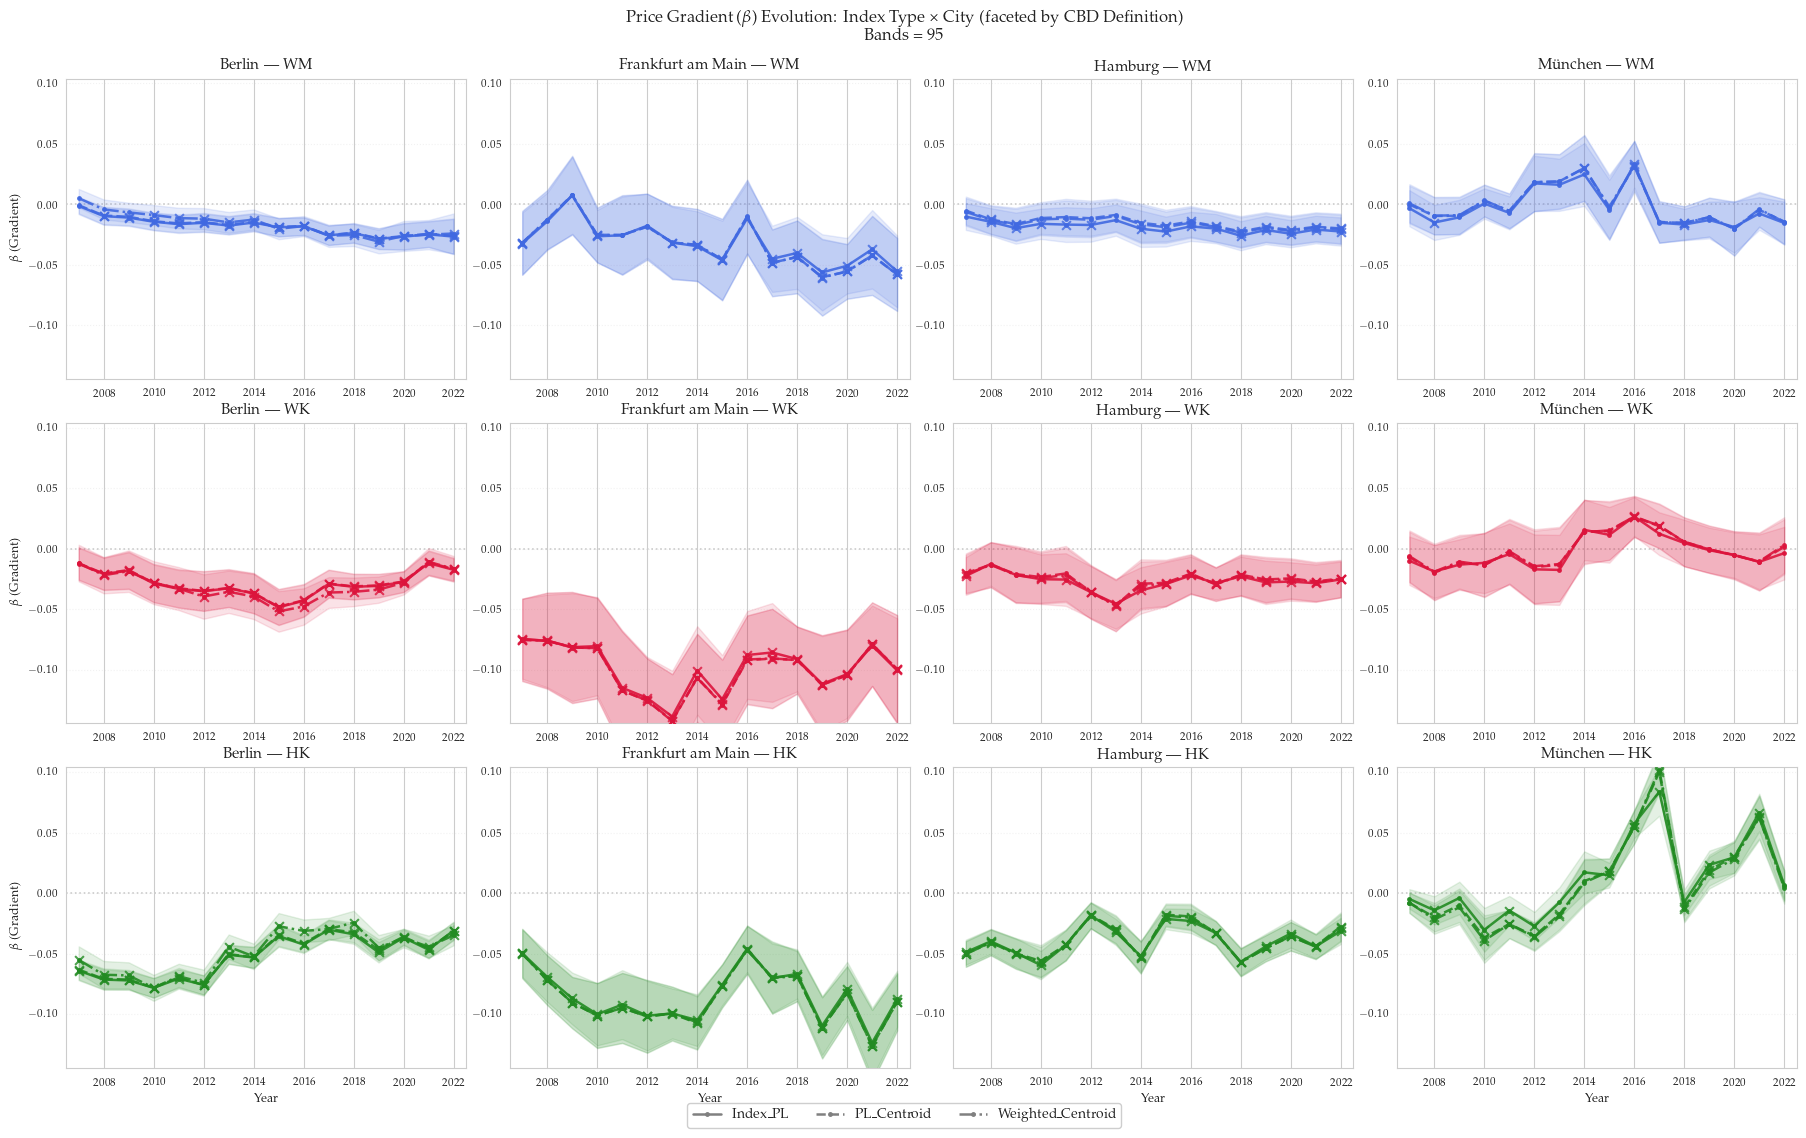

In [ ]:
# VISUALIZATION 1: Time series by Index Type × City (3×4 grid)
# MUCH MORE READABLE: Each subplot only shows CBD type variations (3 lines instead of 9)
# Optimized for 16:10 aspect ratio

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# Primary colors for index types
index_colors = {
    'index_wm': '#4169E1',      # royalblue - wage premium
    'index_wk': '#DC143C',      # firebrick - commercial
    'index_hk': '#228B22'       # forestgreen - residential
}

# Line styles for CBD types (solid, dashed, dash-dot)
linestyles = {cbd: ls for cbd, ls in zip(sorted(cbd_order), ['-', '--', '-.'])}

# Calculate common y-axis limits across all subplots
y_min = betas_viz['beta'].min() - 0.002
y_max = betas_viz['beta'].max() + 0.002

# Create 3×4 grid: 3 rows (index types) × 4 columns (cities) → 16:10 aspect ratio
# Increased figure size to reduce relative spacing
fig, axes = plt.subplots(3, 4, figsize=(18, 11.25))

for row, index_type in enumerate(index_order):
    for col, city in enumerate(city_order):
        ax = axes[row, col]
        city_data = betas_viz[(betas_viz['city'] == city) & 
                              (betas_viz['index'] == index_type)]
        
        # Plot each CBD type (only 3 lines per subplot now!)
        for cbd_idx, cbd_type in enumerate(sorted(cbd_order)):
            subset = city_data[city_data['cbd_type_short'] == cbd_type].sort_values('year')
            
            if len(subset) > 0:
                # Plot confidence band (±1.96*SE) if SE values exist - with low alpha
                if subset['beta_se'].notna().any():
                    ax.fill_between(
                        subset['year'],
                        subset['beta'] - 1.96 * subset['beta_se'],
                        subset['beta'] + 1.96 * subset['beta_se'],
                        alpha=0.05,
                        color=index_colors[index_type]
                    )
                
                # Plot main line with distinct line style per CBD type
                ax.plot(
                    subset['year'],
                    subset['beta'],
                    linestyle=linestyles[cbd_type],
                    color=index_colors[index_type],
                    linewidth=1.8,
                    marker='.',
                    markersize=5,
                    label=cbd_type,
                    alpha=0.9
                )
                
                # Add small x marker for p > 0.05 (NOT significant)
                nonsig = subset[~subset['significant']]
                if len(nonsig) > 0 and nonsig['beta_pvalue'].notna().any():
                    ax.scatter(nonsig['year'], nonsig['beta'], 
                             marker='x', s=40, color=index_colors[index_type], 
                             linewidths=1.5, zorder=5, alpha=0.8)
        
        # Reference line at beta=0 (no distance decay)
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=1.2, alpha=0.4, zorder=0)
        
        # Title: show city name and index type short form
        index_short = index_type.replace('index_', '').upper()
        ax.set_title(f"{city} | {index_short}", fontsize=11, fontweight='bold')
        
        # Only show x-axis label on bottom row
        if row == 2:
            ax.set_xlabel('Year', fontsize=9)
        else:
            ax.set_xlabel('')
        
        # Only show y-axis label on leftmost column
        if col == 0:
            ax.set_ylabel(r'$\beta$ (Gradient)', fontsize=9)
        else:
            ax.set_ylabel('')
        
        ax.grid(True, alpha=0.25, linestyle=':', axis='y')
        ax.set_xlim(2006.5, 2022.5)
        ax.set_ylim(y_min, y_max)
        ax.tick_params(labelsize=8)

# Create common legend at the bottom
cbd_types_sorted = sorted(cbd_order)
legend_handles = [Line2D([0], [0], linestyle=linestyles[cbd], color='gray', linewidth=1.8, marker='.',
                         markersize=5, label=cbd) for cbd in cbd_types_sorted]
fig.legend(handles=legend_handles, loc='lower center', ncol=len(cbd_types_sorted), 
           fontsize=10, framealpha=0.95, bbox_to_anchor=(0.5, -0.005))

plt.suptitle(
    'Price Gradient ($\\beta$) Evolution: Index Type × City (faceted by CBD Definition)\nBands = 95% CI | x = p > 0.05 (not significant) | Linestyle: — = Type1  -- = Type2  ·- = Type3',
    fontsize=12,
    fontweight='bold',
    y=0.995
)
plt.tight_layout(rect=[0, 0.015, 1, 0.993], pad=0.3, h_pad=0.2, w_pad=0.2)
plt.savefig(PLOT_ROOT / "task_3" / "beta_timeseries_by_city.png", dpi=300, bbox_inches='tight')
plt.show()

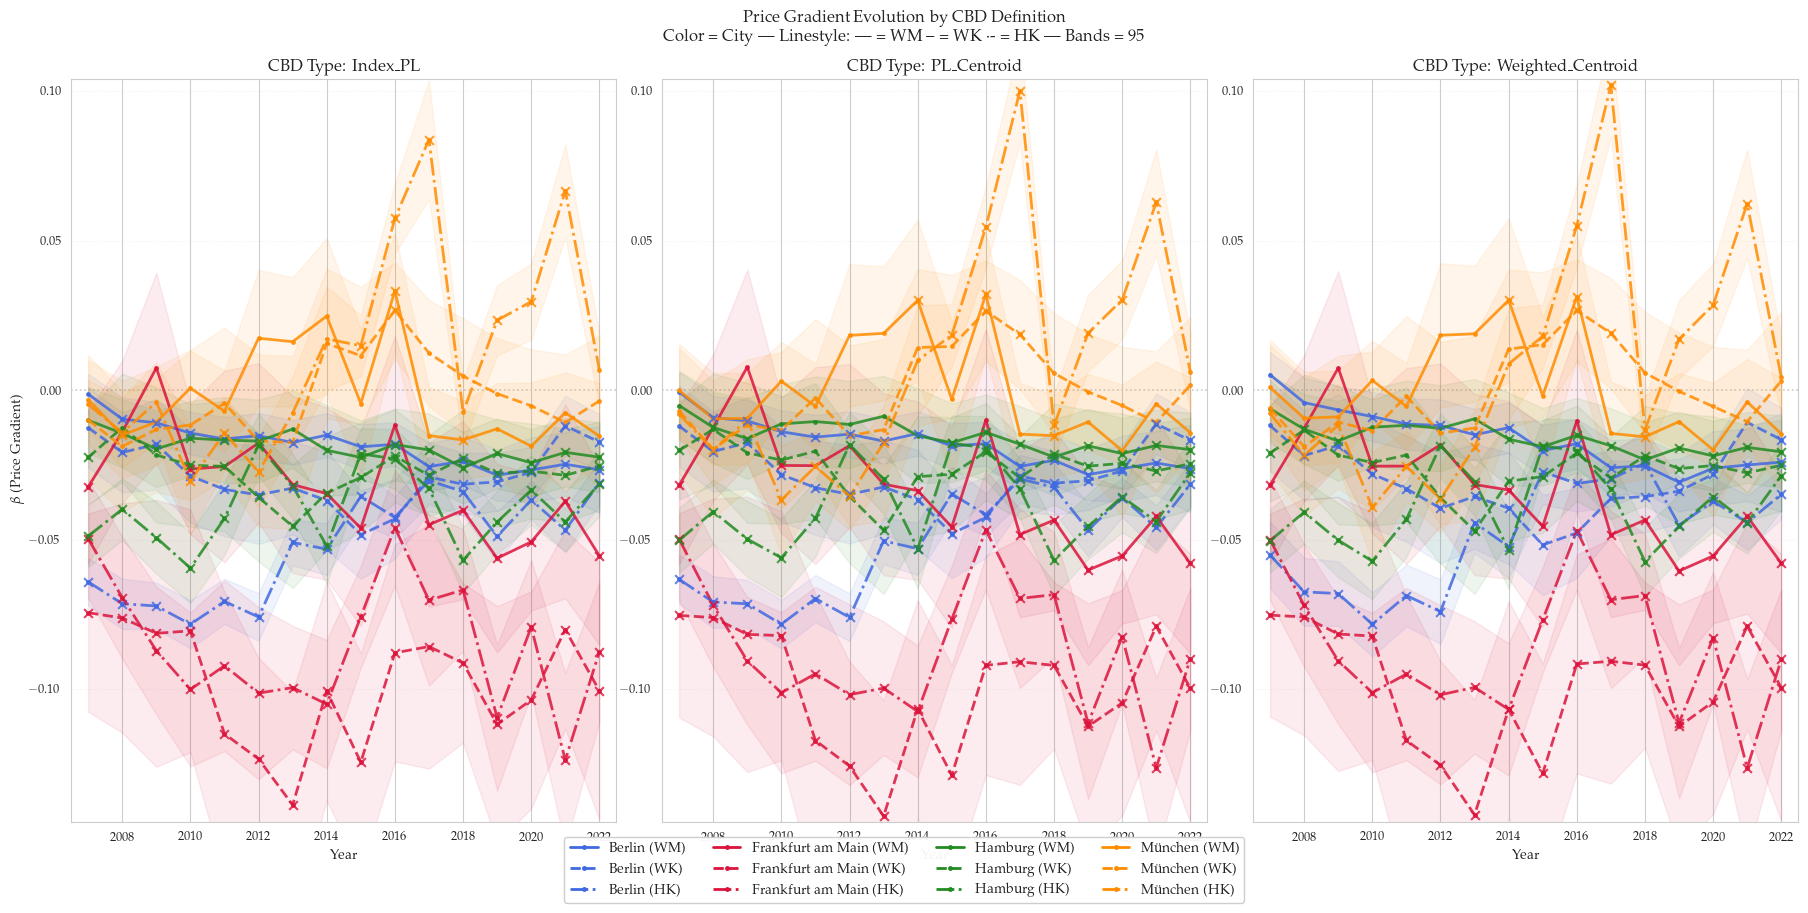

In [ ]:
# VISUALIZATION 2: Time series by CBD Type (1×3 faceted)
# Optimized colors and 16:10 aspect ratio: 18×9 inches
# Colored by city with index type distinguished by line style
# NO confidence bands, includes Köln

# Custom color palette: cities use primary colors + complementary
city_colors = {
    'Berlin': '#4169E1',               # royalblue (primary)
    'Frankfurt am Main': '#DC143C',    # firebrick (primary)
    'Hamburg': '#228B22',              # forestgreen (primary)
    'München': '#FF8C00',              # darkorange (complementary)
    'Köln': '#9370DB'                  # mediumorchid (secondary)
}

# Include all cities for this visualization
cities_for_viz2 = ['Berlin', 'Frankfurt am Main', 'Hamburg', 'München', 'Köln']

# Line styles for index types
index_linestyles = {idx: ls for idx, ls in zip(index_order, ['-', '--', '-.'])}

# Increased figure size to reduce relative spacing
fig, axes = plt.subplots(1, 3, figsize=(18, 9))

# Calculate common y-axis limits across all subplots
y_min = betas_viz['beta'].min() - 0.002
y_max = betas_viz['beta'].max() + 0.002

for cbd_idx, cbd_type in enumerate(sorted(cbd_order)):
    ax = axes[cbd_idx]
    cbd_data = betas_viz[betas_viz['cbd_type_short'] == cbd_type]
    
    # Plot each city
    for city in cities_for_viz2:
        # Within each city, plot all index types
        for index_type in index_order:
            subset = cbd_data[(cbd_data['city'] == city) & 
                            (cbd_data['index'] == index_type)].sort_values('year')
            
            if len(subset) > 0:
                # Plot main line: city color, index type line style (NO confidence bands)
                index_short = index_type.replace('index_', '').upper()
                ax.plot(
                    subset['year'],
                    subset['beta'],
                    linestyle=index_linestyles[index_type],
                    color=city_colors[city],
                    linewidth=2.0,
                    marker='.',
                    markersize=5,
                    alpha=0.85,
                    label=f"{city} ({index_short})"
                )
                
                # Add small x marker for p > 0.05 (NOT significant)
                nonsig = subset[~subset['significant']]
                if len(nonsig) > 0 and nonsig['beta_pvalue'].notna().any():
                    ax.scatter(nonsig['year'], nonsig['beta'], 
                             marker='x', s=40, color=city_colors[city], 
                             linewidths=1.5, zorder=5, alpha=0.8)
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=1.2, alpha=0.4, zorder=0)
    ax.set_title(f"CBD Type: {cbd_type}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    
    # Only show y-axis label on leftmost plot
    if cbd_idx == 0:
        ax.set_ylabel(r'$\beta$ (Price Gradient)', fontsize=10)
    else:
        ax.set_ylabel('')
    
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')
    ax.set_xlim(2006.5, 2022.5)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(labelsize=9)

# Create common legend at bottom for all three subplots
city_index_combos = []
for city in cities_for_viz2:
    for index_type in index_order:
        index_short = index_type.replace('index_', '').upper()
        city_index_combos.append((f"{city} ({index_short})", city, index_type))

legend_handles = []
for label, city, index_type in city_index_combos:
    legend_handles.append(
        Line2D([0], [0], linestyle=index_linestyles[index_type], color=city_colors[city], 
               linewidth=2.0, marker='.', markersize=5, label=label)
    )

fig.legend(handles=legend_handles, loc='lower center', ncol=5, 
           fontsize=10, framealpha=0.95, bbox_to_anchor=(0.5, -0.005))

plt.suptitle(
    'Price Gradient Evolution by CBD Definition (all cities)\nColor = City | Linestyle: — = WM  -- = WK  ·- = HK | x = p > 0.05 (not significant)',
    fontsize=12,
    fontweight='bold',
    y=0.995
)
plt.tight_layout(rect=[0, 0.04, 1, 0.993], pad=0.3, h_pad=0.2, w_pad=0.2)
plt.savefig(PLOT_ROOT / "task_3" / "beta_timeseries_by_cbd.png", dpi=300, bbox_inches='tight')
plt.show()

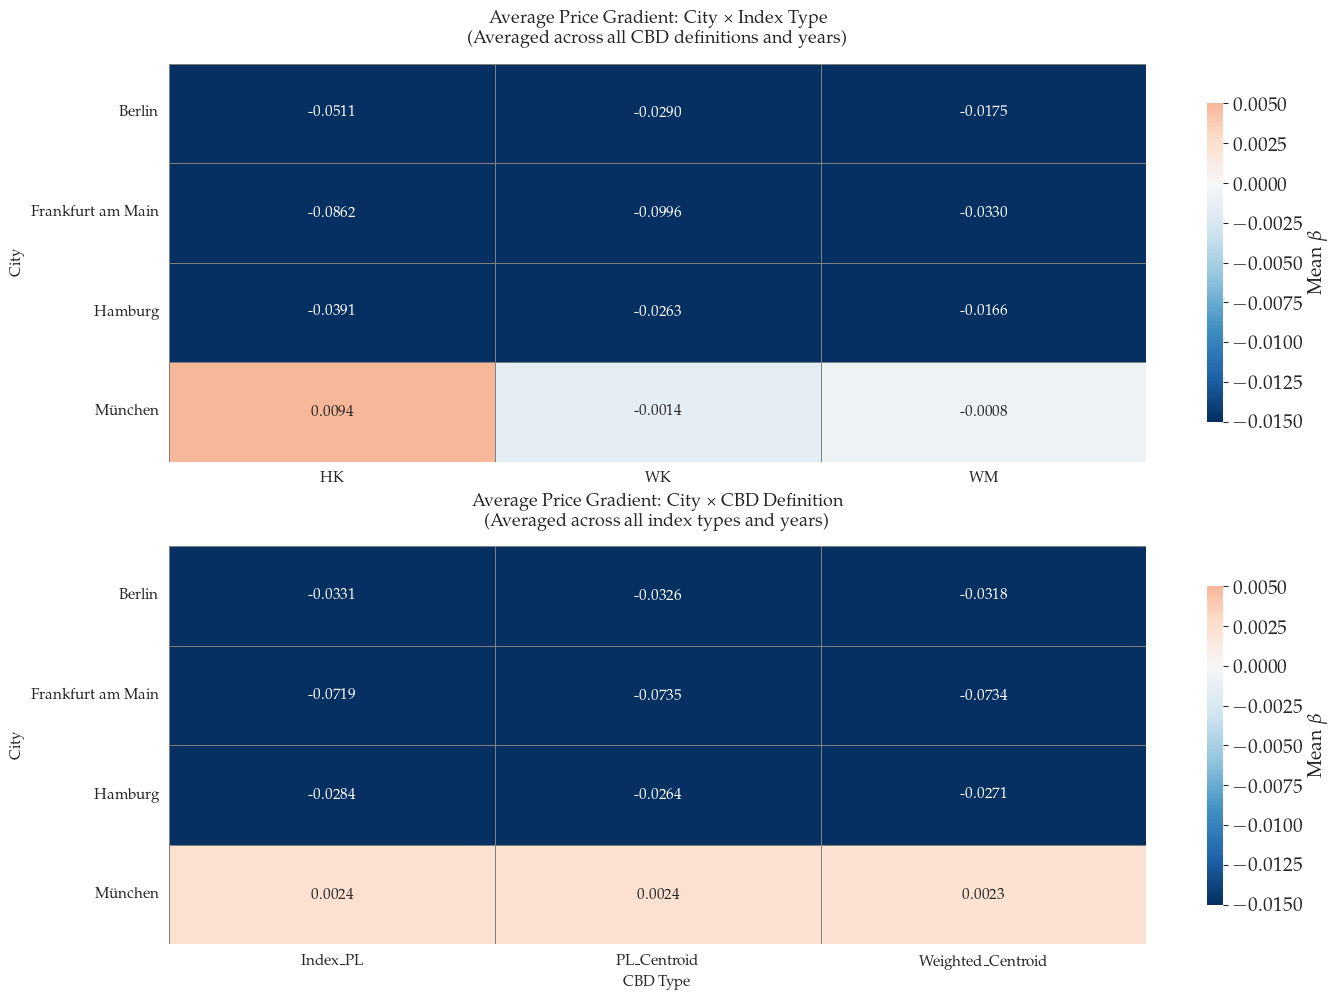

In [47]:
# VISUALIZATION 3: Heatmaps showing average beta by pairs of dimensions
# Top: City × Index Type | Bottom: City × CBD Type
# Optimized colors and 16:10 aspect ratio

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Average across all years and CBD types
city_index_avg = betas_viz.groupby(['city', 'index'])['beta'].mean().unstack()
city_index_avg = city_index_avg.reindex(city_order, fill_value=np.nan)
city_index_avg.columns = [col.replace('index_', '').upper() for col in city_index_avg.columns]

# Use diverging colormap optimized for presentations
sns.heatmap(city_index_avg, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            ax=axes[0], cbar_kws={'label': r'Mean $\beta$', 'shrink': 0.8}, 
            vmin=-0.015, vmax=0.005, annot_kws={'size': 11, 'weight': 'bold'},
            linewidths=0.5, linecolor='gray', square=False)
axes[0].set_title('Average Price Gradient: City × Index Type\n(Averaged across all CBD definitions and years)', 
                  fontweight='bold', fontsize=13, pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('City', fontweight='bold', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=11)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=11, rotation=0)

# Average across all years and index types
city_cbd_avg = betas_viz.groupby(['city', 'cbd_type_short'])['beta'].mean().unstack()
city_cbd_avg = city_cbd_avg.reindex(city_order, fill_value=np.nan)

sns.heatmap(city_cbd_avg, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            ax=axes[1], cbar_kws={'label': r'Mean $\beta$', 'shrink': 0.8}, 
            vmin=-0.015, vmax=0.005, annot_kws={'size': 11, 'weight': 'bold'},
            linewidths=0.5, linecolor='gray', square=False)
axes[1].set_title('Average Price Gradient: City × CBD Definition\n(Averaged across all index types and years)', 
                  fontweight='bold', fontsize=13, pad=15)
axes[1].set_xlabel('CBD Type', fontweight='bold', fontsize=11)
axes[1].set_ylabel('City', fontweight='bold', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=11, rotation=0)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=11, rotation=0)

plt.tight_layout(pad=0.5, h_pad=0.3)
plt.savefig(PLOT_ROOT / "task_3" / "beta_heatmaps_summary.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/4290344756.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax.boxplot([betas_ordered[betas_ordered['city'] == city]['beta'].values for city in city_order],
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/4290344756.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot([betas_idx[betas_idx['index_short'] == idx_short]['beta'].values for idx_short in index_short_order],
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_78719/4290344756.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax.boxplot

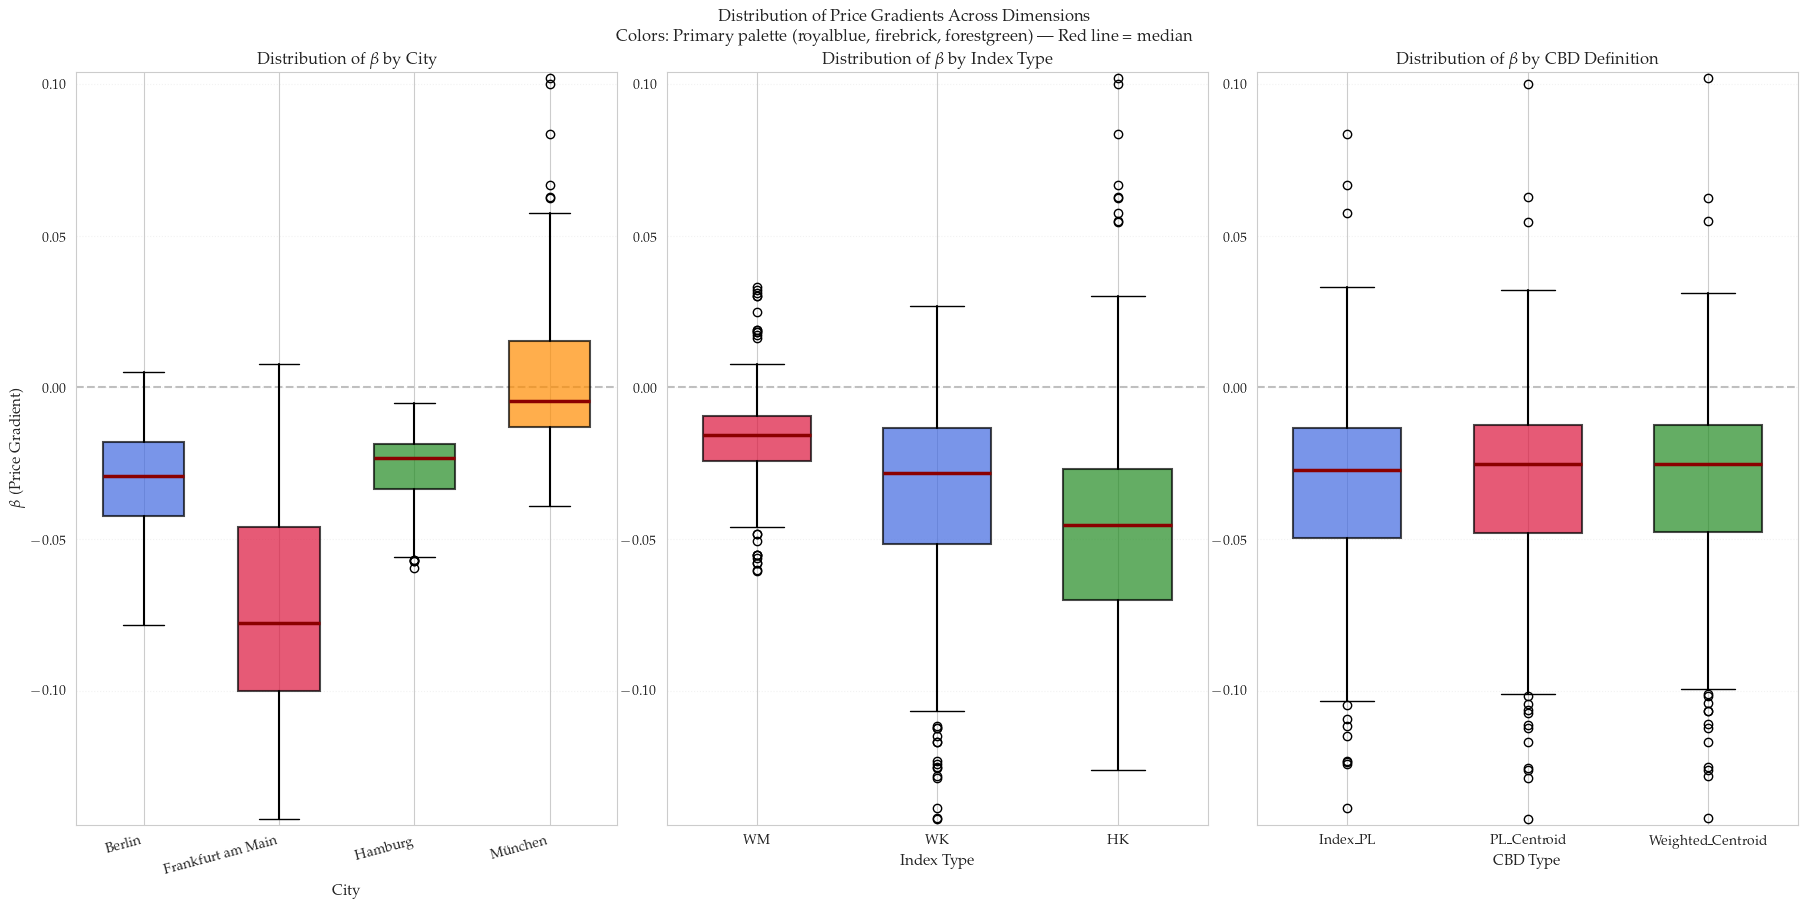

In [ ]:
# VISUALIZATION 4: Distribution view - Box plots across dimensions
# Optimized with primary colors (royalblue, firebrick, forestgreen) and 16:10 aspect ratio
# Includes Köln where available

# Custom color palettes using primary colors
city_palette = {
    'Berlin': '#4169E1',               # royalblue
    'Frankfurt am Main': '#DC143C',    # firebrick
    'Hamburg': '#228B22',              # forestgreen
    'München': '#FF8C00',              # darkorange
    'Köln': '#9370DB'                  # mediumorchid
}

index_palette = {
    'WM': '#DC143C',                   # firebrick
    'WK': '#4169E1',                   # royalblue
    'HK': '#228B22'                    # forestgreen
}

# Three complementary colors for CBD types
cbd_palette = ['#4169E1', '#DC143C', '#228B22']  # royalblue, firebrick, forestgreen

# Calculate common y-axis limits across all subplots
y_min = betas_viz['beta'].min() - 0.002
y_max = betas_viz['beta'].max() + 0.002

# Increased figure size to reduce relative spacing
fig, axes = plt.subplots(1, 3, figsize=(18, 9))

# Left: Distribution by City (including Köln where available)
ax = axes[0]
all_cities_available = sorted(betas_viz['city'].unique())
betas_ordered = betas_viz[betas_viz['city'].isin(all_cities_available)].copy()
betas_ordered['city'] = pd.Categorical(betas_ordered['city'], categories=all_cities_available, ordered=True)
bp1 = ax.boxplot([betas_ordered[betas_ordered['city'] == city]['beta'].values for city in all_cities_available],
                   labels=all_cities_available, widths=0.6, patch_artist=True, 
                   boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                   medianprops=dict(color='darkred', linewidth=2.5))
for patch, city in zip(bp1['boxes'], all_cities_available):
    patch.set_facecolor(city_palette[city])
    patch.set_alpha(0.7)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)
ax.set_title('Distribution of $\\beta$ by City', fontweight='bold', fontsize=12)
ax.set_xlabel('City', fontweight='bold', fontsize=11)
ax.set_ylabel(r'$\beta$ (Price Gradient)', fontweight='bold', fontsize=11)
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.set_xticklabels(all_cities_available, rotation=15, ha='right', fontsize=10)
ax.set_ylim(y_min, y_max)
ax.tick_params(labelsize=10)

# Middle: Distribution by Index Type
ax = axes[1]
betas_idx = betas_viz.copy()
betas_idx['index_short'] = betas_idx['index'].apply(lambda x: x.replace('index_', '').upper())
index_short_order = ['WM', 'WK', 'HK']
bp2 = ax.boxplot([betas_idx[betas_idx['index_short'] == idx_short]['beta'].values for idx_short in index_short_order],
                   labels=index_short_order, widths=0.6, patch_artist=True,
                   boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                   medianprops=dict(color='darkred', linewidth=2.5))
for patch, idx_short in zip(bp2['boxes'], index_short_order):
    patch.set_facecolor(index_palette[idx_short])
    patch.set_alpha(0.7)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)
ax.set_title('Distribution of $\\beta$ by Index Type', fontweight='bold', fontsize=12)
ax.set_xlabel('Index Type', fontweight='bold', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.set_xticklabels(index_short_order, fontsize=10)
ax.set_ylim(y_min, y_max)
ax.tick_params(labelsize=10)

# Right: Distribution by CBD Type
ax = axes[2]
cbd_short_order = sorted(betas_viz['cbd_type_short'].unique())
bp3 = ax.boxplot([betas_viz[betas_viz['cbd_type_short'] == cbd_short]['beta'].values for cbd_short in cbd_short_order],
                   labels=cbd_short_order, widths=0.6, patch_artist=True,
                   boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                   medianprops=dict(color='darkred', linewidth=2.5))
for patch, color in zip(bp3['boxes'], cbd_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, zorder=0)
ax.set_title('Distribution of $\\beta$ by CBD Definition', fontweight='bold', fontsize=12)
ax.set_xlabel('CBD Type', fontweight='bold', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.set_xticklabels(cbd_short_order, fontsize=10)
ax.set_ylim(y_min, y_max)
ax.tick_params(labelsize=10)

plt.suptitle('Distribution of Price Gradients Across Dimensions\nColors: Primary palette (royalblue, firebrick, forestgreen, darkorange) | Red line = median',
             fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout(pad=0.3, h_pad=0.2, w_pad=0.2)
plt.savefig(PLOT_ROOT / "task_3" / "beta_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

## Visualization Summary & Interpretation Guide

### **Chart 1: Time Series by City (RECOMMENDED PRIMARY)**
**Best for:** Understanding temporal trends and city-specific patterns

- **X-axis:** Year (2007–2022)
- **Y-axis:** $\beta$ coefficient (price gradient in %/km)
- **Rows:** Four major cities (Berlin, Frankfurt, Hamburg, München)
- **Line colors:** Index type (Red=wage premium WM, Blue=commercial WK, Green=residential HK)
- **Line style:** CBD definition (solid=Index_PL, dashed=Weighted_Centroid, dash-dot=PL_Centroid)
- **Shaded band:** 95% confidence interval (±1.96 × SE)
- **X markers:** Non-significant results (p ≥ 0.05)

**Interpretation:** Negative $\beta$ means prices decay with distance from CBD (expected for urban economics). Steeper (more negative) gradients = stronger centrality effect.

---

### **Chart 2: Time Series by CBD Type**
**Best for:** Assessing robustness of results to different CBD definitions

- **Columns:** Three CBD definitions
- **Line colors:** Cities
- **Shows:** Whether conclusions change with different centrality measures

---

### **Chart 3: Heatmaps (Summary Statistics)**
**Best for:** Quick overview of average effects and ranking

- **Top heatmap:** Average $\beta$ by City × Index Type
- **Bottom heatmap:** Average $\beta$ by City × CBD Type
- **Color intensity:** Red (negative $\beta$) to Blue (positive $\beta$)
- **Uses:** Identify which combinations are most economically important

**Key insight:** Most values should be negative (distance decay effect).

---

### **Chart 4: Box Plot Distributions**
**Best for:** Identifying outliers and comparing variability

- **Left:** Cities with widest variation?
- **Middle:** Which index shows strongest distance decay?
- **Right:** Are estimates robust to CBD definition?

---

### **Design Choices Explained:**
1. **Multiple small multiples** → Each subplot is self-contained and comparable
2. **Confidence bands** → Show statistical uncertainty without clutter
3. **Significance markers (X)** → Immediately identify non-significant results
4. **Reference line at β=0** → Helps assess economic meaning
5. **Consistent color schemes** → Easy cross-plot comparison


In [49]:
# Summary Statistics & Key Insights

print("=" * 80)
print("KEY FINDINGS FROM BETA GRADIENT ANALYSIS")
print("=" * 80)

print("\n1. AVERAGE PRICE GRADIENTS BY CITY:")
city_summary = betas_viz.groupby('city')['beta'].agg(['mean', 'std', 'min', 'max', 'count'])
print(city_summary.round(5))

print("\n2. AVERAGE PRICE GRADIENTS BY INDEX TYPE:")
index_summary = betas_viz.groupby('index')['beta'].agg(['mean', 'std', 'min', 'max'])
print(index_summary.round(5))

print("\n3. AVERAGE PRICE GRADIENTS BY CBD TYPE:")
cbd_summary = betas_viz.groupby('cbd_type_short')['beta'].agg(['mean', 'std', 'min', 'max'])
print(cbd_summary.round(5))

print("\n4. TEMPORAL TRENDS (2007 vs 2022):")
early = betas_viz[betas_viz['year'] <= 2010]['beta'].mean()
recent = betas_viz[betas_viz['year'] >= 2020]['beta'].mean()
print(f"   Average β (2007-2010): {early:.6f}")
print(f"   Average β (2020-2022): {recent:.6f}")
print(f"   Change: {recent - early:+.6f}")

print("\n5. STATISTICAL SIGNIFICANCE:")
sig = betas_viz['significant'].sum()
total = len(betas_viz)
print(f"   Significant results (p<0.05): {sig}/{total} = {100*sig/total:.1f}%")

print("\n6. TOP 10 MOST NEGATIVE GRADIENTS (strongest CBD effect):")
top_gradients = betas_viz.nsmallest(10, 'beta')[['city', 'index', 'cbd_type_short', 'year', 'beta']]
print(top_gradients.to_string())

print("\n" + "=" * 80)

KEY FINDINGS FROM BETA GRADIENT ANALYSIS

1. AVERAGE PRICE GRADIENTS BY CITY:
                      mean      std      min      max  count
city                                                        
Berlin            -0.03253  0.01878 -0.07822  0.00520    144
Frankfurt am Main -0.07293  0.03490 -0.14236  0.00779    144
Hamburg           -0.02733  0.01280 -0.05944 -0.00508    144
Köln              -0.03581  0.02531 -0.08448  0.00225     48
München            0.00237  0.02439 -0.03911  0.10203    144

2. AVERAGE PRICE GRADIENTS BY INDEX TYPE:
             mean      std      min      max
index                                       
index_hk -0.04316  0.04034 -0.12623  0.10203
index_wk -0.03907  0.03781 -0.14236  0.02673
index_wm -0.01633  0.01677 -0.06041  0.03324

3. AVERAGE PRICE GRADIENTS BY CBD TYPE:
                      mean      std      min      max
cbd_type_short                                       
Index_PL          -0.03337  0.03359 -0.13862  0.08381
PL_Centroid       -0.032